In [1]:
%load_ext autoreload
%autoreload 0

In [2]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]
sys.path.append(str(Path().resolve().parents[1]))

In [3]:
import os
import re

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from io import StringIO
import pandas as pd
import pickle
import igraph as ig
import torch



In [4]:
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()


from dataset import CachedDataset
from collate import collate_fn

from model import DiffusionGNN
from diff_util import create_diffusion, preprocess


# ----------------------------------
# Config
# ----------------------------------

BATCH_SIZE = 32          # you can increase now
LR = 2e-4
EPOCHS = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NODE_DIM = 3
HIDDEN = 128
TIMESTEPS = 1000
MAX_NODES = 300  

# ----------------------------------
# Dataset
# ----------------------------------

dataset = CachedDataset("cached_dataset.pt", max_nodes=MAX_NODES)
print(f"Dataset size: {len(dataset)}")

loader = DataLoader(

    dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collate_fn,

    num_workers=0,      # IMPORTANT
    pin_memory=False,    # IMPORTANT

    persistent_workers=False,
)

print(f"Number of batches: {len(loader)}")
model = DiffusionGNN(
    node_dim=NODE_DIM,
    hidden_dim=HIDDEN,
    num_layers=4
).to(DEVICE)

diffusion = create_diffusion(TIMESTEPS)
print(f"Model and diffusion created on {DEVICE}")

optimizer = Adam(model.parameters(), lr=LR)


# ----------------------------------
# Training
# ----------------------------------

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    print(f"Epoch {epoch+1}/{EPOCHS} | Training...")

    for x, adj, node_mask in loader:

        x = x.to(DEVICE, dtype=torch.float16)
        adj = adj.to(DEVICE, dtype=torch.float16) # 500 x 500 adjacency matrix = 250,000 entries = 4000 x 4000 x 4 bytes = 64 MB per graph, batch size 2 = 128 MB just for adj, plus node features and other tensors, so we need to be careful with memory
        node_mask = node_mask.to(DEVICE, dtype=torch.float16)

        # print(adj.shape, node_mask.shape)

        # Mask adj
        adj = adj * node_mask[:, :, None] * node_mask[:, None, :]
        # print(adj.shape, node_mask.shape)
        # print(adj)
        # break
        B = x.shape[0]


        t = torch.randint(
            0,
            diffusion.num_timesteps,
            (B,),
            device=DEVICE
        )


        with autocast():

            loss_dict = diffusion.training_losses(
                model,
                x_start=x,
                t=t,
                model_kwargs={
                    "adj": adj,
                    "node_mask": node_mask
                }
            )

            loss = loss_dict["loss"].mean()


        optimizer.zero_grad()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()


        total_loss += loss.item()


    avg_loss = total_loss / len(loader)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")


    torch.save(model.state_dict(), "model.pt")

Filtered dataset: 2724 → 2722 graphs (max_nodes=300)
Dataset size: 2722
Number of batches: 86
Model and diffusion created on cuda
Epoch 1/50 | Training...
Epoch 1 | Loss: 2.6372
Epoch 2/50 | Training...
Epoch 2 | Loss: 1.1234
Epoch 3/50 | Training...
Epoch 3 | Loss: 0.9990
Epoch 4/50 | Training...
Epoch 4 | Loss: 0.9420
Epoch 5/50 | Training...
Epoch 5 | Loss: 0.9008
Epoch 6/50 | Training...
Epoch 6 | Loss: 0.8830
Epoch 7/50 | Training...
Epoch 7 | Loss: 0.8684
Epoch 8/50 | Training...
Epoch 8 | Loss: 0.8649
Epoch 9/50 | Training...
Epoch 9 | Loss: 0.8583
Epoch 10/50 | Training...
Epoch 10 | Loss: 0.8436
Epoch 11/50 | Training...
Epoch 11 | Loss: 0.8521
Epoch 12/50 | Training...
Epoch 12 | Loss: 0.7999
Epoch 13/50 | Training...
Epoch 13 | Loss: 0.8038
Epoch 14/50 | Training...
Epoch 14 | Loss: 0.8254
Epoch 15/50 | Training...
Epoch 15 | Loss: 0.8298
Epoch 16/50 | Training...
Epoch 16 | Loss: 0.8229
Epoch 17/50 | Training...
Epoch 17 | Loss: 0.8199
Epoch 18/50 | Training...
Epoch 18 | L

In [13]:

# ============================================================
# Inspection setup — run this cell before the ones below
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from dataset import CachedDataset
from model import DiffusionGNN
from diff_util import create_diffusion

DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
TIMESTEPS = 100
NODE_DIM  = 3
HIDDEN    = 128

# Load dataset and pick a sample with at least 6 nodes
dataset    = CachedDataset("cached_dataset.pt")
sample_idx = next(i+4 for i, (x, _) in enumerate(dataset) if x.shape[0] >= 6)
x_orig, adj_orig = dataset[sample_idx]
N = x_orig.shape[0]

print(f"Sample index : {sample_idx}")
print(f"Nodes        : {N}")
print(f"Node features (laundering, degree, depth):\n{x_orig}")

# Add batch dimension — all inspection cells work with [1, N, ...] tensors
x_batch   = x_orig.unsqueeze(0).float().to(DEVICE)   # [1, N, 3]
adj_batch = adj_orig.unsqueeze(0).float().to(DEVICE)  # [1, N, N]
node_mask = torch.ones(1, N, device=DEVICE)           # [1, N]

# Load trained model
model = DiffusionGNN(node_dim=NODE_DIM, hidden_dim=HIDDEN, num_layers=4).to(DEVICE)
model.load_state_dict(torch.load("model.pt", map_location=DEVICE))
model.eval()
print(f"\nModel loaded on {DEVICE}")

diffusion = create_diffusion(TIMESTEPS)
print("Diffusion created.")


Sample index : 5
Nodes        : 27
Node features (laundering, degree, depth):
tensor([[ 1.,  4.,  0.],
        [ 0.,  5.,  2.],
        [ 1.,  7.,  0.],
        [ 1., 40.,  0.],
        [ 0.,  6.,  2.],
        [ 0.,  4.,  2.],
        [ 0.,  2.,  2.],
        [ 0., 26.,  1.],
        [ 0.,  5.,  2.],
        [ 0.,  4.,  2.],
        [ 0.,  6.,  2.],
        [ 0.,  3.,  2.],
        [ 0.,  3.,  2.],
        [ 0., 11.,  1.],
        [ 0., 11.,  1.],
        [ 0., 14.,  2.],
        [ 0., 20.,  1.],
        [ 0.,  3.,  2.],
        [ 0.,  5.,  2.],
        [ 0., 22.,  1.],
        [ 0.,  5.,  2.],
        [ 0.,  5.,  2.],
        [ 0.,  4.,  2.],
        [ 0.,  1.,  2.],
        [ 0., 46.,  2.],
        [ 0.,  2.,  1.],
        [ 0.,  2.,  2.]])

Model loaded on cuda
Diffusion created.


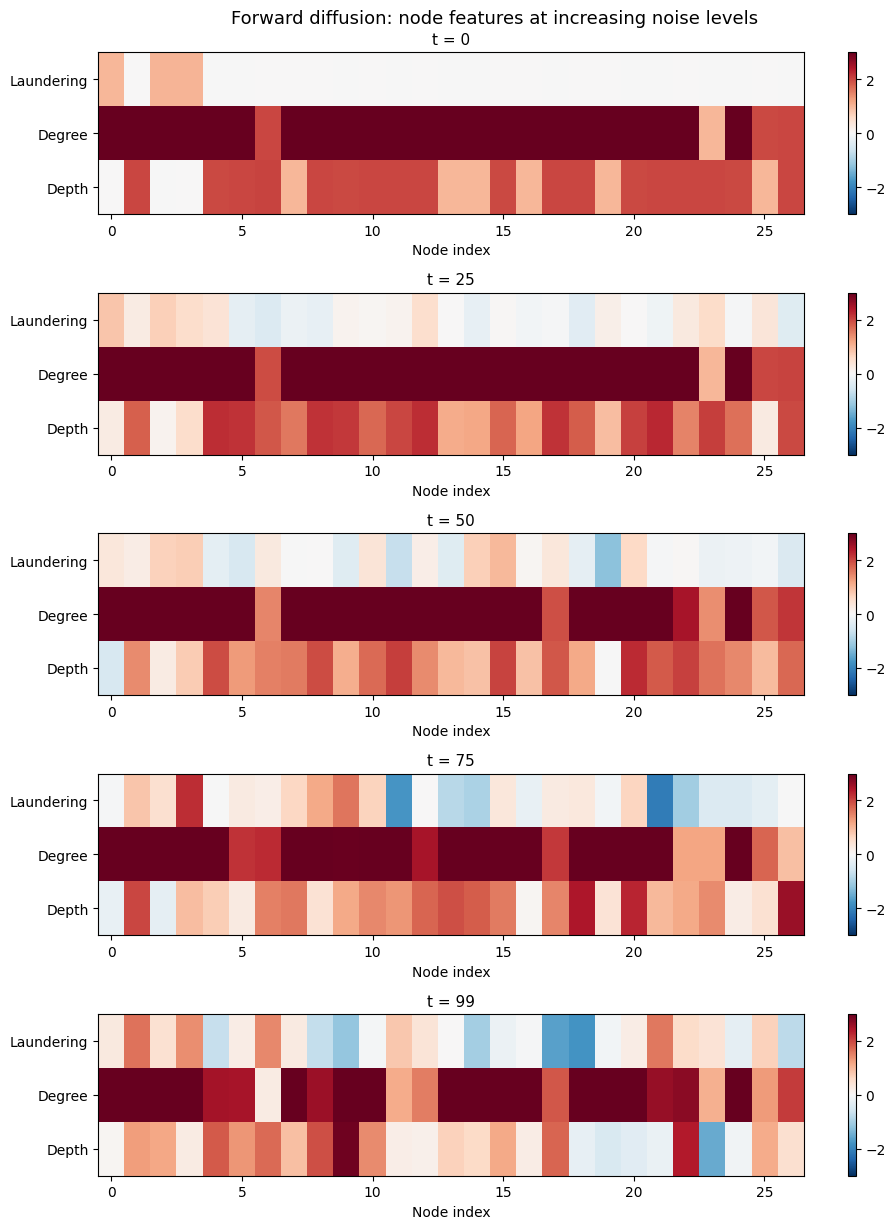

In [14]:

# ============================================================
# 1. Forward corruption — q_sample at increasing timesteps
# ============================================================

checkpoints   = [0, 25, 50, 75, 99]
feature_names = ["Laundering", "Degree", "Depth"]

fig, axes = plt.subplots(len(checkpoints), 1, figsize=(10, 2.5 * len(checkpoints)))

with torch.no_grad():
    for ax, t_val in zip(axes, checkpoints):
        t_tensor = torch.tensor([t_val], device=DEVICE)
        x_t = diffusion.q_sample(x_batch, t_tensor, node_mask=node_mask)
        data = x_t[0].cpu().float().numpy()   # [N, 3]
        im = ax.imshow(data.T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
        ax.set_title(f"t = {t_val}", fontsize=11)
        ax.set_yticks(range(3))
        ax.set_yticklabels(feature_names)
        ax.set_xlabel("Node index")
        plt.colorbar(im, ax=ax)

plt.suptitle("Forward diffusion: node features at increasing noise levels", fontsize=13)
plt.tight_layout()
plt.show()


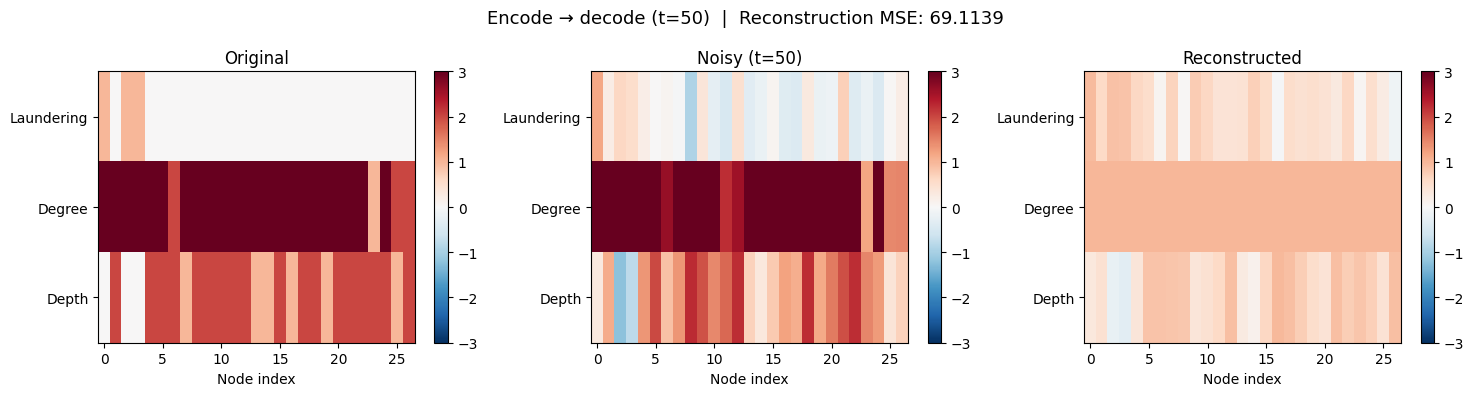

  Laundering   MSE: 0.2045
  Degree       MSE: 205.8898
  Depth        MSE: 1.2475


In [15]:

# ============================================================
# 2. Encode → decode reconstruction at a chosen t
# ============================================================

def denoise_from_t(model, diffusion, x_t, adj, node_mask, start_t, device):
    """Run the reverse diffusion loop from `start_t` down to 0."""
    x = x_t.clone()
    with torch.no_grad():
        for i in reversed(range(start_t + 1)):
            t = torch.tensor([i] * x.shape[0], device=device)
            out = diffusion.p_sample(
                model, x, t,
                model_kwargs={"adj": adj, "node_mask": node_mask},
            )
            x = out["sample"]
    return x


T_ENCODE = 50   # noise level to encode to — try 25, 50, 75

with torch.no_grad():
    t_tensor = torch.tensor([T_ENCODE], device=DEVICE)
    x_noisy = diffusion.q_sample(x_batch, t_tensor, node_mask=node_mask)

x_recon = denoise_from_t(model, diffusion, x_noisy, adj_batch, node_mask, T_ENCODE, DEVICE)

feature_names = ["Laundering", "Degree", "Depth"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, title, tensor in zip(
    axes,
    ["Original", f"Noisy (t={T_ENCODE})", "Reconstructed"],
    [x_batch,    x_noisy,                  x_recon],
):
    data = tensor[0].cpu().float().numpy()
    im = ax.imshow(data.T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
    ax.set_title(title, fontsize=12)
    ax.set_yticks(range(3))
    ax.set_yticklabels(feature_names)
    ax.set_xlabel("Node index")
    plt.colorbar(im, ax=ax)

mse = ((x_batch.float() - x_recon.float()) ** 2).mean().item()
plt.suptitle(f"Encode → decode (t={T_ENCODE})  |  Reconstruction MSE: {mse:.4f}", fontsize=13)
plt.tight_layout()
plt.show()

# Per-feature MSE
for i, name in enumerate(feature_names):
    feat_mse = ((x_batch[0, :, i].float() - x_recon[0, :, i].float()) ** 2).mean().item()
    print(f"  {name:12s} MSE: {feat_mse:.4f}")


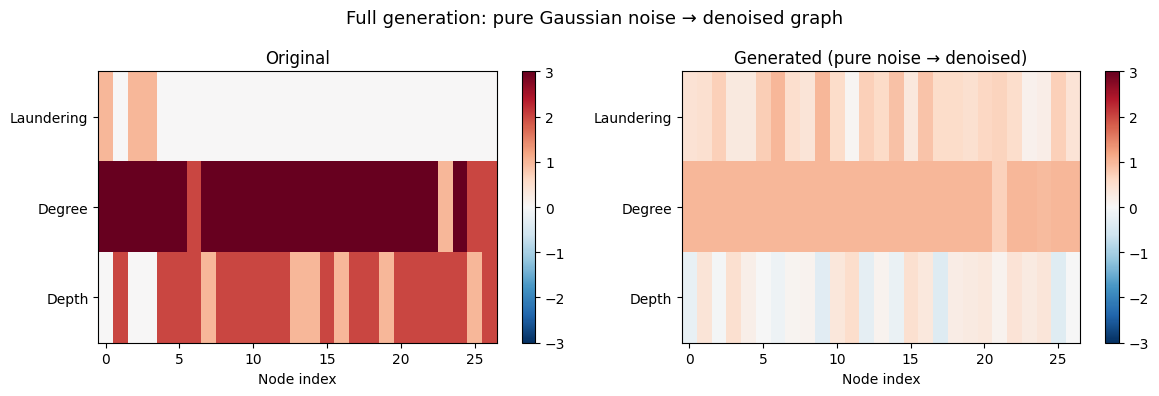

Laundering    orig mean=0.111  gen mean=0.544  orig std=0.314  gen std=0.237
Degree        orig mean=9.852  gen mean=0.987  orig std=11.293  gen std=0.057
Depth         orig mean=1.556  gen mean=0.110  orig std=0.685  gen std=0.276


In [16]:

# ============================================================
# 3. Full generation from pure noise (p_sample_loop)
# ============================================================
# Uses the real graph's adj + node_mask as conditioning structure,
# but starts node features from pure Gaussian noise.

shape = x_batch.shape  # [1, N, 3]

with torch.no_grad():
    x_generated = diffusion.p_sample_loop(
        model,
        shape,
        model_kwargs={"adj": adj_batch, "node_mask": node_mask},
        device=DEVICE,
    )

feature_names = ["Laundering", "Degree", "Depth"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, title, tensor in zip(
    axes,
    ["Original", "Generated (pure noise → denoised)"],
    [x_batch, x_generated],
):
    data = tensor[0].cpu().float().numpy()
    im = ax.imshow(data.T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
    ax.set_title(title, fontsize=12)
    ax.set_yticks(range(3))
    ax.set_yticklabels(feature_names)
    ax.set_xlabel("Node index")
    plt.colorbar(im, ax=ax)

plt.suptitle("Full generation: pure Gaussian noise → denoised graph", fontsize=13)
plt.tight_layout()
plt.show()

# Distribution stats
orig_np = x_batch[0].cpu().float().numpy()
gen_np  = x_generated[0].cpu().float().numpy()
for i, name in enumerate(feature_names):
    print(f"{name:12s}  orig mean={orig_np[:, i].mean():.3f}  gen mean={gen_np[:, i].mean():.3f}  "
          f"orig std={orig_np[:, i].std():.3f}  gen std={gen_np[:, i].std():.3f}")


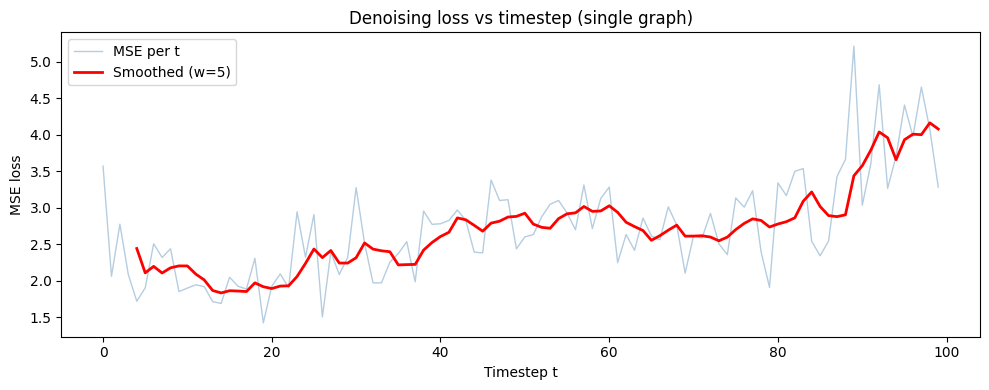

Easiest t (lowest loss): 19  loss=1.4230
Hardest t (highest loss): 89  loss=5.2103


In [17]:

# ============================================================
# 4. Per-timestep loss curve — MSE vs t on one graph
# ============================================================

losses_per_t = []

model.eval()
with torch.no_grad():
    for t_val in range(TIMESTEPS):
        t_tensor = torch.tensor([t_val], device=DEVICE)
        loss_dict = diffusion.training_losses(
            model,
            x_start=x_batch,
            t=t_tensor,
            model_kwargs={"adj": adj_batch, "node_mask": node_mask},
        )
        losses_per_t.append(loss_dict["loss"].item())

window = max(1, TIMESTEPS // 20)
smoothed = np.convolve(losses_per_t, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(range(TIMESTEPS), losses_per_t, alpha=0.4, linewidth=1, color="steelblue", label="MSE per t")
plt.plot(range(window - 1, TIMESTEPS), smoothed, linewidth=2, color="red", label=f"Smoothed (w={window})")
plt.xlabel("Timestep t")
plt.ylabel("MSE loss")
plt.title("Denoising loss vs timestep (single graph)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Easiest t (lowest loss): {int(np.argmin(losses_per_t))}  loss={min(losses_per_t):.4f}")
print(f"Hardest t (highest loss): {int(np.argmax(losses_per_t))}  loss={max(losses_per_t):.4f}")


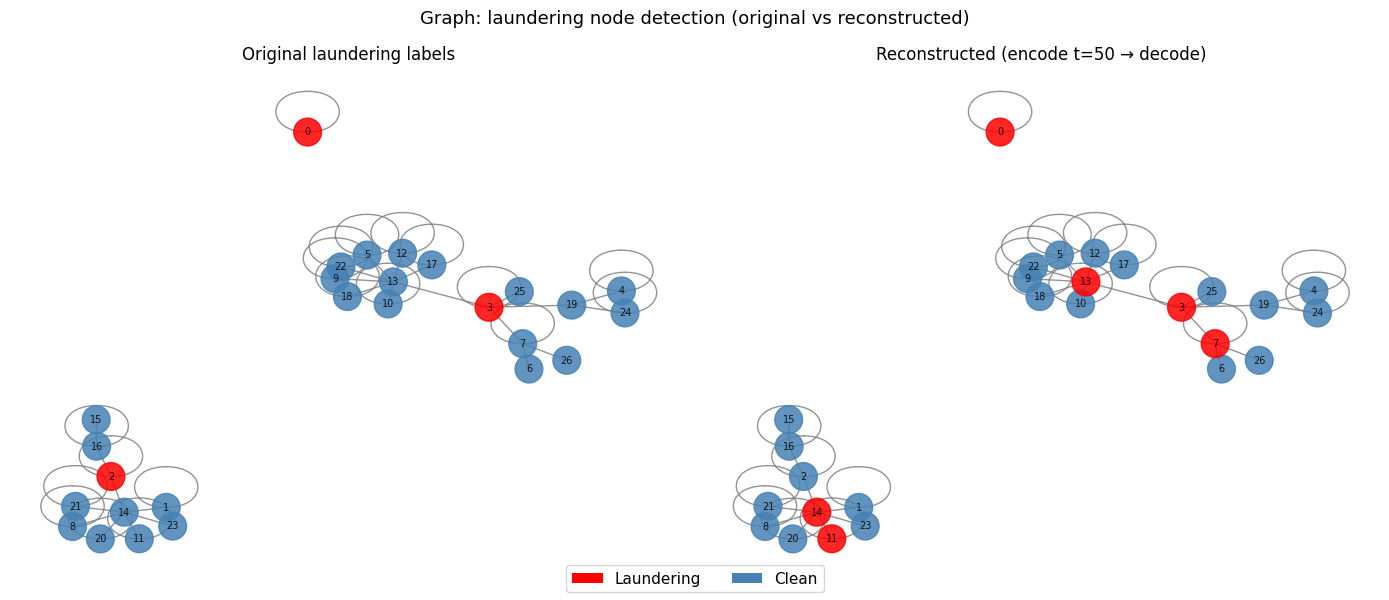

Laundering label accuracy after encode-decode: 81.48%


In [18]:

# ============================================================
# 5. Graph visualization — original vs reconstructed laundering
# ============================================================
# Requires Cell C (encode-decode) to have been run first.

T_VIZ = 50

with torch.no_grad():
    t_tensor = torch.tensor([T_VIZ], device=DEVICE)
    x_noisy_viz = diffusion.q_sample(x_batch, t_tensor, node_mask=node_mask)

x_recon_viz = denoise_from_t(model, diffusion, x_noisy_viz, adj_batch, node_mask, T_VIZ, DEVICE)

adj_np       = adj_orig.cpu().numpy()
G            = nx.from_numpy_array(adj_np)
pos          = nx.spring_layout(G, seed=42)

orig_labels  = x_orig[:, 0].numpy()                        # feature 0 = laundering
recon_labels = x_recon_viz[0, :, 0].cpu().float().numpy()
recon_binary = (recon_labels > 0.5).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, labels, title in zip(
    axes,
    [orig_labels, recon_binary],
    ["Original laundering labels", f"Reconstructed (encode t={T_VIZ} → decode)"],
):
    colors = ["red" if l > 0.5 else "steelblue" for l in labels]
    nx.draw_networkx(
        G, pos=pos, ax=ax,
        node_color=colors, node_size=400,
        with_labels=True, font_size=7,
        edge_color="grey", alpha=0.85,
    )
    ax.set_title(title, fontsize=12)
    ax.axis("off")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="red",      label="Laundering"),
    Patch(facecolor="steelblue", label="Clean"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=11)
plt.suptitle("Graph: laundering node detection (original vs reconstructed)", fontsize=13)
plt.tight_layout()
plt.show()

# Accuracy of laundering label reconstruction
correct = ((recon_binary > 0.5) == (orig_labels > 0.5)).mean()
print(f"Laundering label accuracy after encode-decode: {correct:.2%}")
